In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("vgsales.csv")

In [3]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
df.shape

(16598, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [6]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [7]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [8]:
df = df.dropna(subset=['Year'])
df['Publisher'] = df['Publisher'].fillna('Unknown')

In [10]:
df['Year'] = df['Year'].astype(int)

In [11]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


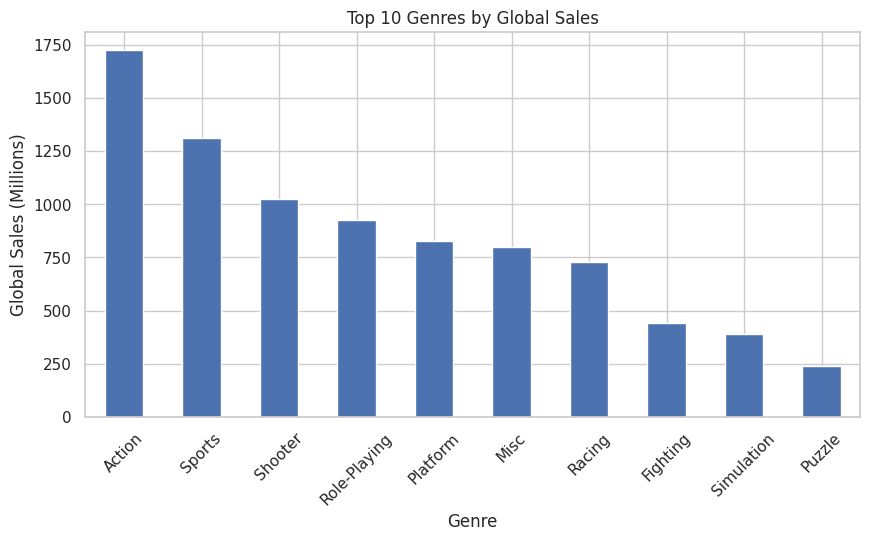

In [12]:
genre_sales = (
    df.groupby('Genre')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
genre_sales.plot(kind='bar')
plt.title("Top 10 Genres by Global Sales")
plt.xlabel("Genre")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45)
plt.show()

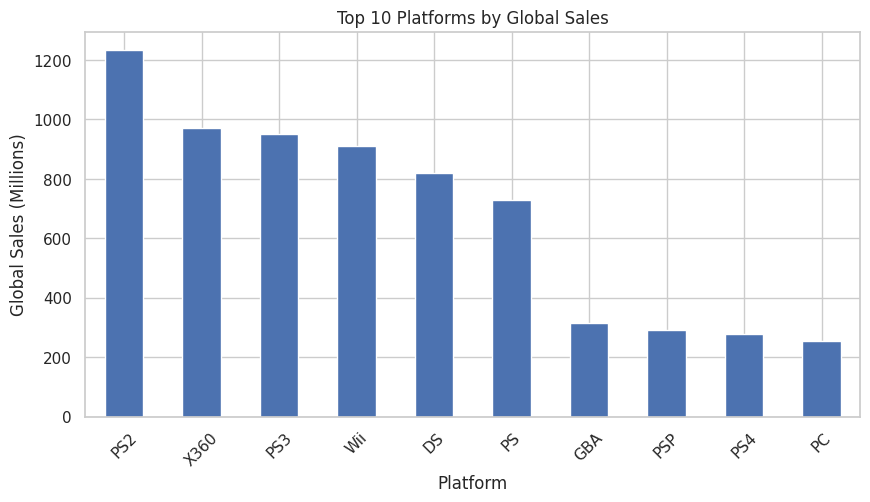

In [13]:
platform_sales = (
    df.groupby('Platform')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
platform_sales.plot(kind='bar')
plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Platform")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45)
plt.show()

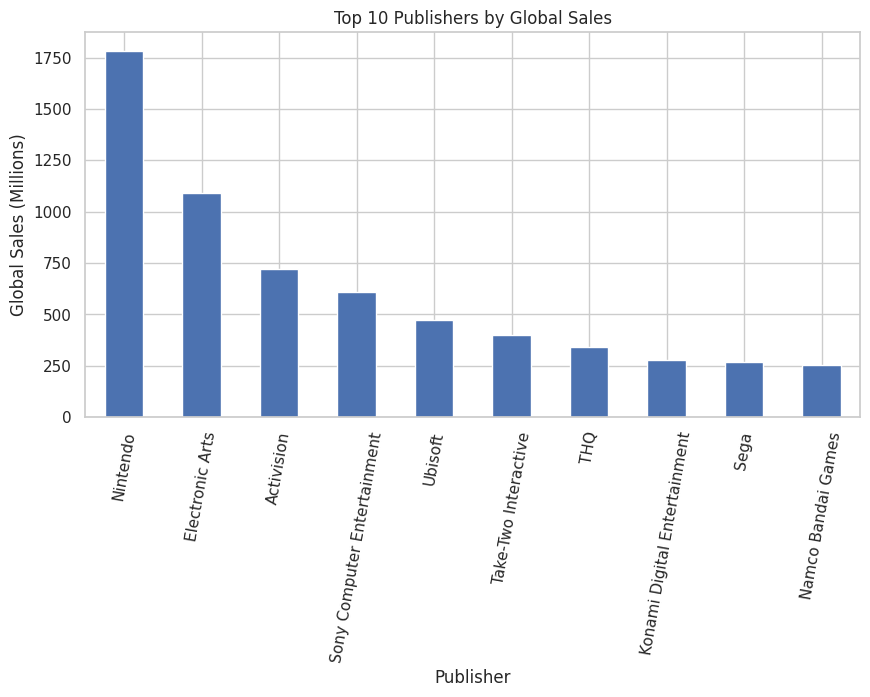

In [22]:
publisher_sales = (
    df.groupby('Publisher')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
publisher_sales.plot(kind='bar')
plt.title("Top 10 Publishers by Global Sales")
plt.xlabel("Publisher")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=80)
plt.show()

In [23]:
regional_totals = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Global_Sales']].sum()
regional_percentage = (regional_totals / regional_totals['Global_Sales']) * 100
regional_percentage[['NA_Sales', 'EU_Sales', 'JP_Sales']]

,0
NA_Sales,49.129854
EU_Sales,27.313171
JP_Sales,14.560630


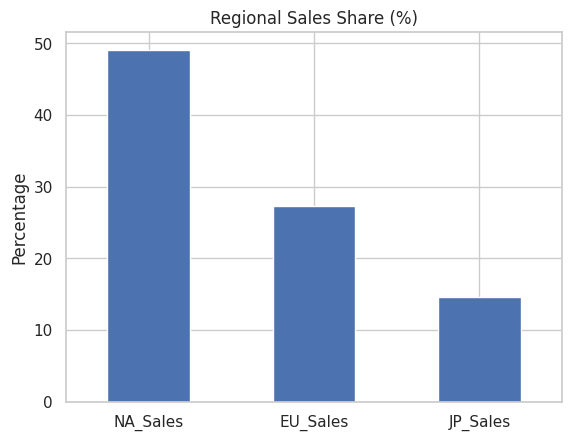

In [24]:
regional_percentage[['NA_Sales', 'EU_Sales', 'JP_Sales']].plot(kind='bar')
plt.title("Regional Sales Share (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [25]:
na_genre = df.groupby('Genre')['NA_Sales'].sum().idxmax()
eu_genre = df.groupby('Genre')['EU_Sales'].sum().idxmax()
jp_genre = df.groupby('Genre')['JP_Sales'].sum().idxmax()

print("NA:", na_genre)
print("EU:", eu_genre)
print("JP:", jp_genre)

NA: Action
EU: Action
JP: Role-Playing


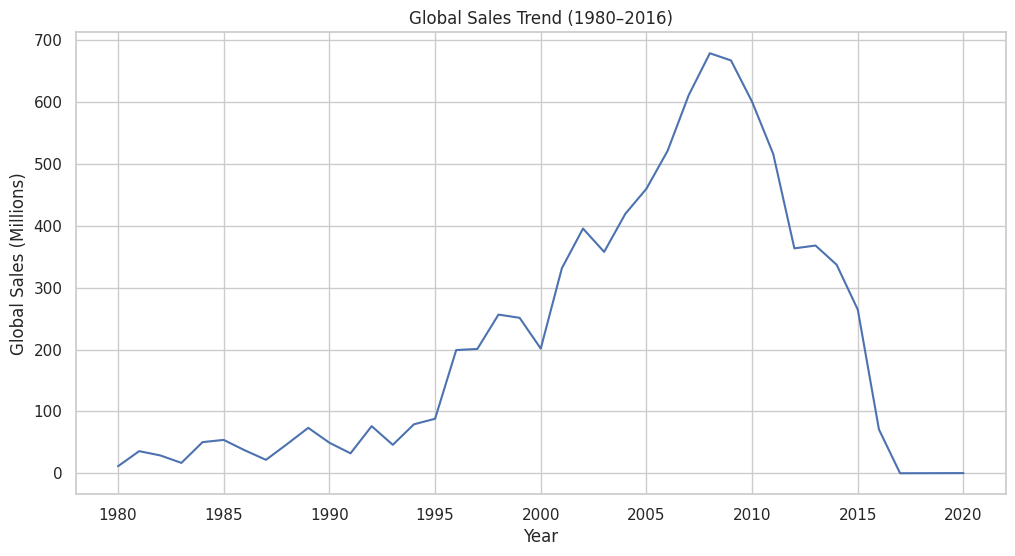

In [26]:
yearly_sales = df.groupby('Year')['Global_Sales'].sum()
plt.figure(figsize=(12,6))
yearly_sales.plot()
plt.title("Global Sales Trend (1980–2016)")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.show()

In [27]:
top_games = df.sort_values(by='Global_Sales', ascending=False).head(10)
top_games[['Name', 'Platform', 'Genre', 'Global_Sales']]

,Name,Platform,Genre,Global_Sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,Tetris,GB,Puzzle,30.26
6,New Super Mario Bros.,DS,Platform,30.01
7,Wii Play,Wii,Misc,29.02
8,New Super Mario Bros. Wii,Wii,Platform,28.62
9,Duck Hunt,NES,Shooter,28.31


In [32]:
# Create decade column
def get_decade(year):
    if year < 1990:
        return "80s"
    elif year < 2000:
        return "90s"
    elif year < 2010:
        return "2000s"
    else:
        return "2010s"

df['Decade'] = df['Year'].apply(get_decade)



decade_sales = (
    df.groupby('Decade')['Global_Sales']
      .mean()
      .sort_values(ascending=False)
)

decade_sales


,Global_Sales
Decade,
80s,1.836976
90s,0.722956
2000s,0.504346
2010s,0.489961


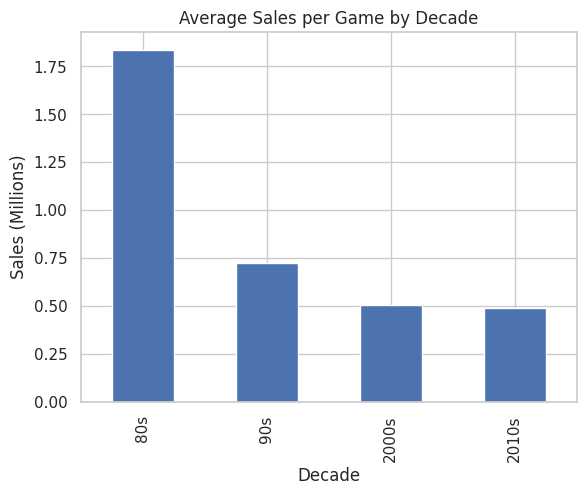

In [33]:
decade_sales.plot(kind='bar')

plt.title("Average Sales per Game by Decade")
plt.ylabel("Sales (Millions)")
plt.show()

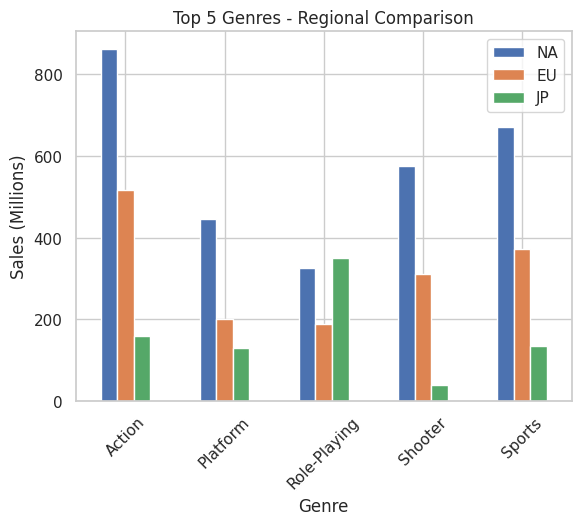

In [34]:
top5_genres = (
    df.groupby('Genre')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

filtered = df[df['Genre'].isin(top5_genres)]

region_genre = filtered.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()

region_genre.plot(kind='bar')

plt.title("Top 5 Genres - Regional Comparison")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.legend(["NA", "EU", "JP"])
plt.show()

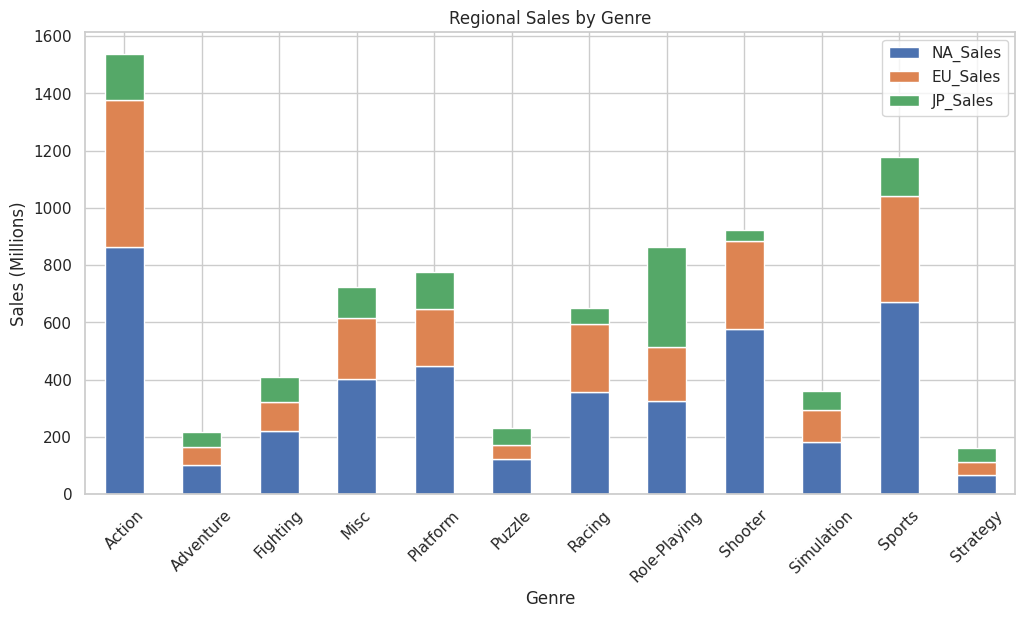

In [37]:
genre_region = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()

genre_region.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Regional Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.show()